# Linear Regression — Concepts

Read the idea, the formula and the small example in that order. The demonstration code is provided.

## Libraries and settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

## 1. The model and its coefficients

For area $x$ and monthly rent $y$:
$$y=\beta_0+\beta_1x+\varepsilon,\qquad \hat y=\hat\beta_0+\hat\beta_1x.$$
$\beta_0$ is the intercept, $\beta_1$ the slope and $\varepsilon$ an error term. A slope of 20 means one extra m² is associated with 20 CHF more rent on average. Zero area is usually outside the useful range, so the intercept has little practical meaning.

With several inputs:
$$\hat y=\hat\beta_0+\hat\beta_1\,\mathrm{area}+\hat\beta_2\,\mathrm{rooms}.$$
The area coefficient means increasing area **while keeping the included number of rooms constant** (ceteris paribus). An association is not automatically a causal effect. “Linear” means linear in the coefficients; an input such as $x^2$ is allowed.

## 2. Ordinary least squares (OLS)

A residual is $e_i=y_i-\hat y_i$: observed minus predicted. OLS chooses the line with the smallest sum of squared residuals:
$$\mathrm{SSE}=\sum(y_i-\hat y_i)^2.$$
With one predictor:
$$\hat\beta_1=\frac{\sum(x_i-\bar x)(y_i-\bar y)}{\sum(x_i-\bar x)^2},\qquad \hat\beta_0=\bar y-\hat\beta_1\bar x.$$
The numerator describes how x and y move together; the denominator describes the spread of x. The line passes through $(\bar x,\bar y)$.

Areas 40, 60, 80 and rents 1200, 1600, 2000 give slope 20 and intercept 400. A prediction at 95 m² is 2300 CHF. This is an illustrative extrapolation beyond this small example's observed range.

In [2]:
x = np.array([40, 60, 80])
y = np.array([1200, 1600, 2000])
slope = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)
intercept = y.mean() - slope * x.mean()
print('Slope:', slope, 'Intercept:', intercept)
print('95 m²:', intercept + slope * 95)

Slope: 20.0 Intercept: 400.0
95 m²: 2300.0


## 3. RMSE and R²

RMSE expresses error in CHF. R² compares squared error with predicting the mean:
$$\mathrm{RMSE}=\sqrt{\frac1n\sum(y_i-\hat y_i)^2},\qquad R^2=1-\frac{\mathrm{SSE}}{\mathrm{SST}},\qquad \mathrm{SST}=\sum(y_i-\bar y)^2.$$
For SSE = 20 and SST = 100, R² = 0.8. OLS with an intercept gives training R² between 0 and 1. Test R² can be negative: predictions can be worse than the test-set mean. High training R² alone does not establish good new predictions.

## 4. Confidence versus prediction intervals

A 95% **confidence interval** concerns the average rent at a given area. A 95% **prediction interval** concerns one new apartment. The latter is wider because individual apartments scatter around the average.

Simple OLS intervals are $\hat y(x_0)\pm t\times\mathrm{SE}$:
$$\mathrm{SE}_{\mathrm{mean}}=s\sqrt{\frac1n+\frac{(x_0-\bar x)^2}{\sum(x_i-\bar x)^2}},\qquad \mathrm{SE}_{\mathrm{new}}=s\sqrt{1+\frac1n+\frac{(x_0-\bar x)^2}{\sum(x_i-\bar x)^2}}.$$
$x_0$ is the new area, $s$ estimates residual scatter and $t$ is the multiplier for the confidence level ($n-2$ degrees of freedom). The extra **1** makes the prediction interval wider. Python does the calculation; you interpret the bounds. Validity depends on the model assumptions.

## 5. Assumptions and diagnostics

| Assumption | Meaning | Check |
|---|---|---|
| Linearity | average follows the specified model | residuals versus fitted values |
| Independence | rows do not depend on each other | data collection and time order |
| Equal variance | similar residual scatter across fitted values | residuals versus fitted values |
| Normal errors | approximately bell-shaped errors | Q–Q plot |
| No perfect multicollinearity | inputs do not determine each other exactly | correlations |

Normality is needed for exact small-sample t/F inference, not for computing OLS. Strongly correlated inputs make individual coefficients uncertain. VIF measures that issue; its calculation is not required here. A plot can suggest problems, but cannot prove every assumption.

## 6. Maximum likelihood and gradient descent

**Maximum likelihood** chooses parameters that make observed data most plausible. For one particular sequence of seven heads and three tails:
$$L(p)=p^7(1-p)^3.$$
It is greatest at $p=0.7$. With independent normal errors of constant variance, maximum likelihood and OLS give the same regression line.

**Gradient descent** starts with a guess and takes small steps downhill on the loss surface:
$$\beta_{\mathrm{new}}=\beta_{\mathrm{old}}-\eta\,\mathrm{gradient}.$$
$\eta$ is the learning rate; too large a step can overshoot. Stochastic gradient descent uses an observation or a small batch per step. The demonstration below walks towards the minimum of $(b-3)^2$.

p: 0.5 Likelihood: 0.000977
p: 0.7 Likelihood: 0.002224
p: 0.9 Likelihood: 0.000478


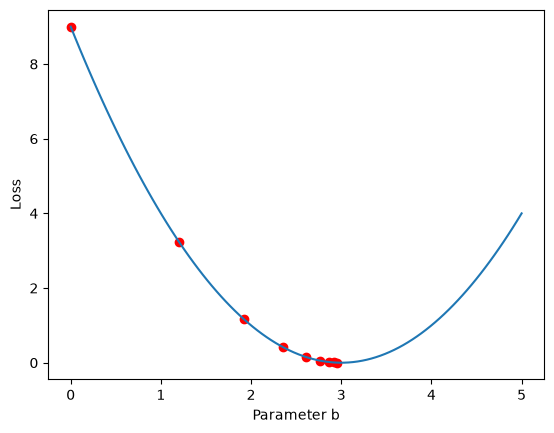

In [3]:
for p in [0.5, 0.7, 0.9]:
    print('p:', p, 'Likelihood:', round(p ** 7 * (1 - p) ** 3, 6))
b = 0.0
positions = [b]
for step in range(8):
    gradient = 2 * (b - 3)
    b = b - 0.2 * gradient
    positions.append(b)
grid = np.linspace(0, 5, 100)
plt.plot(grid, (grid - 3) ** 2)
plt.scatter(positions, (np.array(positions) - 3) ** 2, color='red')
plt.xlabel('Parameter b')
plt.ylabel('Loss')
plt.show()

### Jupyter notebook — footer info

Include this information when submitting your notebook.

In [4]:
import platform
from datetime import datetime
print(platform.platform())
print("Python:", platform.python_version())
print("Date:", datetime.now().isoformat(timespec="seconds"))

Linux-6.8.0-1064-azure-x86_64-with-glibc2.41
Python: 3.11.16
Date: 2026-10-02T19:10:33
